# Data Cleaning and Feature Engineering

After getting an understanding of our features and how they relate in part 1 (/titanic1.ipynb), we can start to clean up our data and also perform some feature engineering based off our results in preparation for model training. Like before, let's start by importing libraries and loading our data.

In [237]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("train.csv")
print(f"Original shape: {df.shape}")
df.head()

Original shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Let's also do the missing value analysis from before.

In [238]:
missing_vals = df.isna().sum()
print("Missing values before cleaning: ")
print(missing_vals)

print(f"\n Total missing: {df.isna().sum().sum()}")

Missing values before cleaning: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 Total missing: 866


## Handling Missing Values

### Cabin

Cabin is missing 77% of the time, so we may want to delete the variable. However, we can check if the existence of cabin data somehow relates to survival.

In [239]:
has_cabin_surv = df[df["Cabin"].isna() == False]["Survived"].mean()
no_cabin_surv = df[df["Cabin"].isna() == True]["Survived"].mean()

print(f"Survival rate if has cabin info: {has_cabin_surv:.2%}")
print(f"Survival rate if no cabin info: {no_cabin_surv:.2%}")

Survival rate if has cabin info: 66.67%
Survival rate if no cabin info: 29.99%


The existance of cabin info seems correlated to survival, so we can drop Cabin data and introduce a new column that just defines whether there exists Cabin data or not

In [240]:
df["HasCabin"] = df["Cabin"].notna().astype(int)
df = df.drop(columns=["Cabin"])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


For the missing age data, we can fill in missing data with the median age given gender and passenger class. Note that doing groupby([list]) produces a multi-index. 

In [241]:
median_ages = df.groupby(["Pclass", "Sex"])["Age"].median()
median_ages

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [242]:
# fill with group median
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

# fill any edge cases with overall median
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Missing Age values after filling:", df["Age"].isna().sum())

Missing Age values after filling: 0


Let's visualize what the age data looks like now with everything filled in.

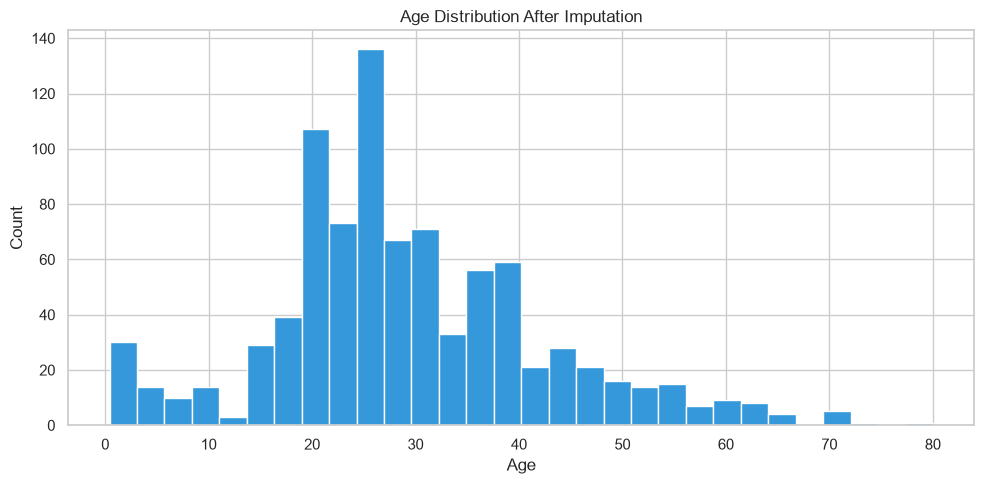

In [243]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["Age"], bins=30, color="#3498db", edgecolor="white")
ax.set_title("Age Distribution After Imputation")
ax.set_xlabel("Age")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

We have dealt with Cabin and Age, so all there is to deal with now is the Embarked missing. The first solution is simply to drop those two records that have no embarked data.

In [244]:
print(df.dropna().shape)
print(df[df["Embarked"].notna()].shape)

(889, 12)
(889, 12)


Alternatively, we can fill the missing data with the mode. 

In [245]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# mode by gender example
# df.groupby("Sex")["Embarked"].transform(lambda x: x.fillna(x.mode()))

In [246]:
df.isna().sum().sum()

np.int64(0)

## Feature Engineering

Now, let's use the information we gained from our feature analysis in part 1 to construct new features for use by our model. For example, we noted that title had a significant relationship with survival, so we can define that as a feature.

In [247]:
df["Title"] = df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

We can use a Python map where every common title gets mapped with itself and every other title gets mapped to "Rare" using __map.get(x, default_val)__

In [248]:
# Group rare titles together
common_list = {
    "Mr": "Mr",
    "Mrs": "Mrs",
    "Miss": "Miss",
    "Master": "Master"
}

df["Title"] = df["Title"].apply(lambda x: common_list.get(x, "Rare"))
print(df["Title"].value_counts())

df.groupby("Title")["Survived"].mean()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


Title
Master    0.575000
Miss      0.697802
Mr        0.156673
Mrs       0.792000
Rare      0.444444
Name: Survived, dtype: float64

### Family Size and isAlone

In [249]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = df["FamilySize"].apply(lambda x: 1 if x == 1 else 0) # alternatively, df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print(f"Solo travelers: {df['IsAlone'].sum()} ({df['IsAlone'].mean():.1%})")
print(f"\nSurvival rate - alone: {df[df['IsAlone'] == 1]['Survived'].mean():.2%}")
print(f"Survival rate - not alone: {df[df['IsAlone'] == 0]['Survived'].mean():.2%}")

Solo travelers: 537 (60.3%)

Survival rate - alone: 30.35%
Survival rate - not alone: 50.56%


### Age Groups

We can bin ages into specific groups by using the __pd.cut()__ method. The method segments continuous variables into categorical variables with the following parameters:

- X, the input array to be binned (must be 1D)
- bins (int for equal width bins that contains all the data points, a sequence of numbers that defines the bin edges, or interval index describing exact bins)
- labels, defines the labels for each bin, so must be same length as bins (or one less if using the bin edges because $edges = bins + 1$)

In [250]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 80], labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

print("Age Group Distribution:")
print(df["AgeGroup"].value_counts().sort_index())
print("\nSurvival rate by age group:")
print(df.groupby("AgeGroup")["Survived"].mean())

Age Group Distribution:
AgeGroup
Child           69
Teen            70
Young Adult    514
Adult          216
Senior          22
Name: count, dtype: int64

Survival rate by age group:
AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.357977
Adult          0.384259
Senior         0.227273
Name: Survived, dtype: float64


An alternative to cutting by bins (discrete values) is to cut based on quartiles. For this, use the __pd.qcut()__ method, and the most important difference is that instead of defining bins, you define $q$ for the number of quartiles you want to cut with.

### Fare Bins

In [251]:
df["FareBin"] = pd.qcut(df["Fare"], q=4, labels=["Low", "Medium", "High", "Very High"])

print("Survival rate by Fare Bin:")
print(df.groupby("FareBin")["Survived"].mean())

Survival rate by Fare Bin:
FareBin
Low          0.197309
Medium       0.303571
High         0.454955
Very High    0.581081
Name: Survived, dtype: float64


## Encoding Categorical Variables

We need to either convert all string/object/categorical variables into numeric variables before using them in a model, or drop them. Use __df.dtypes__ to get the datatypes of all the columns. An important technique to note is __one-hot encoding__. This converts a single object/categorical column with a few options into multiple columns where each is a boolean 0/1 based on if the row has that specific category (original column is deleted). So, if there are 3 possibilities of Embarked (C, Q, S), we convert Embarked into 3 boolean columns for C, Q, and S. The method is __pd.get_dummies()__, and the arguments are:

- df: specific dataframe
- columns: column names to be one-hot encoded (if none passed, all object and string columns will be)
- drop_first: wether to get k-1 dummies out of k categorical levels by removing the first level (saving one column)
- dtype: resulting column datatype
- prefix: if you want to prepend a string to the new one-hot column names

In [252]:
df.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name                str
Sex                 str
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Embarked            str
HasCabin          int64
Title               str
FamilySize        int64
IsAlone           int64
AgeGroup       category
FareBin        category
dtype: object

In [253]:
# Let's first map the Sex column to 0 and 1
df["Sex"] = df["Sex"].map({"male": 0, "female": 1}) # alternative: df["Sex"].apply(lambda x: 0 if x == "male" else 1)

df = pd.get_dummies(df, columns=["Embarked", "Title", "AgeGroup", "FareBin"], drop_first=True, dtype=int)

print(f"Shape after one-hot: {df.shape}")
df.head()

Shape after one-hot: (891, 26)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,1,0,0,0,1,0,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,0,1,0,0,0,1,0,0,0,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,1,0,0,1,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,0,1,0,0,1,0,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,1,0,0,0,1,0,0,1,0,0


Now, let's drop unnnecessary columns

In [254]:
print(f"Original columns: {df.columns.tolist()}")
drop_cols = ["PassengerId", "Name", "Ticket"]

df = df.drop(columns=drop_cols)
print(f"Final Shape: {df.shape}")
print(f"Final columns: {df.columns.tolist()}")

Original columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareBin_Medium', 'FareBin_High', 'FareBin_Very High']
Final Shape: (891, 23)
Final columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareBin_Medium', 'FareBin_High', 'FareBin_Very High']


Let's do a final check on our data cleaning.

In [255]:
print("Missing values: ")
print(df.isna().sum().sum())
print("\nColumn info:")
print(df.dtypes)

Missing values: 
0

Column info:
Survived                  int64
Pclass                    int64
Sex                       int64
Age                     float64
SibSp                     int64
Parch                     int64
Fare                    float64
HasCabin                  int64
FamilySize                int64
IsAlone                   int64
Embarked_Q                int64
Embarked_S                int64
Title_Miss                int64
Title_Mr                  int64
Title_Mrs                 int64
Title_Rare                int64
AgeGroup_Teen             int64
AgeGroup_Young Adult      int64
AgeGroup_Adult            int64
AgeGroup_Senior           int64
FareBin_Medium            int64
FareBin_High              int64
FareBin_Very High         int64
dtype: object


## Save Clean Data

Finally, let's save this cleaned data in a new CSV file so we can load this when we start model training. 

In [256]:
df.to_csv("titanic_cleaned.csv", index=False)
print("Cleaned dataset saved to titanic_cleaned.csv")
print(f"Final shape: {df.shape}")
df.head()

Cleaned dataset saved to titanic_cleaned.csv
Final shape: (891, 23)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,0,3,0,22.0,1,0,7.2500,0,2,0,...,1,0,0,0,1,0,0,0,0,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,...,0,1,0,0,0,1,0,0,0,1
2,1,3,1,26.0,0,0,7.9250,0,1,1,...,0,0,0,0,1,0,0,1,0,0
3,1,1,1,35.0,1,0,53.1000,1,2,0,...,0,1,0,0,1,0,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,1,1,...,1,0,0,0,1,0,0,1,0,0


## Markdown

| Step | Action |
|---|---|
| Cabin | Created HasCabin flag, then dropped raw column |
| Age | Imputed missing values using group median (Pclass, Sex) |
| Embarked | Filled 2 missing values with mode (S) |
| Title | Extracted from Name, grouped rare titles |
| FamilySize | Created from SibSp + Parch + 1 |
| IsAlone | Binary flag for solo travelers |
| AgeGroup | Binned Age into 5 categories |
| FareBin | Binned Fare into quartiles |
| Encoding | Label encoded Sex, one-hot encoded categoricals |
| Dropped | PassengerId, Name, Ticket (not useful for modeling) |